In [51]:
from astropy.io import fits
from astropy.table import Table
from calc_kcor import calc_kcor

t = Table.read('HSC_SSP_zphoto.fits')




In [52]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
import matplotlib as mpl


z_val = np.linspace(0, 1.5, 100)

age_vals = cosmo.age(z_val).to(u.Myr)

age = 10**t['age_photo']
z_phot = t['z_photo']
sel = np.isfinite(z_phot) & np.isfinite(age)


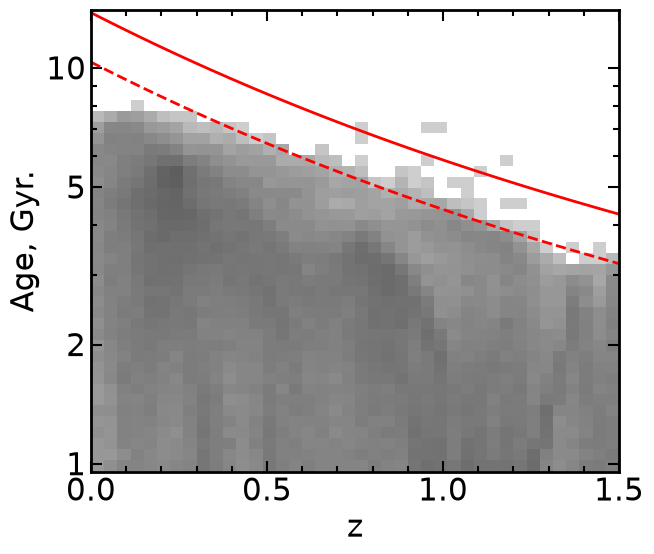

In [115]:
age_gyr = 10**t['age_photo'] / 1e3

mask = (
    np.isfinite(z_phot) &
    np.isfinite(age_gyr) &
    sel &
    (age_gyr >= 0.95) &
    (age_gyr <= 10.0)
)

xbins = np.linspace(0.0, 1.5, 41)
ybins = np.logspace(-0.1, 1, 41)   # 1–10 Gyr

plt.figure(figsize=(7, 6))

plt.hist2d(
    z_phot[mask],
    age_gyr[mask],
    bins=[xbins, ybins],
    norm=mpl.colors.LogNorm(vmin=0.01, vmax=50000),
    cmap='Greys'
)

plt.plot(z_val, age_vals/ 1e3, color='red', lw=2)

plt.plot(z_val, age_vals * 0.75 / 1e3, color='red', linestyle='--', lw=2)

plt.yscale('log')
plt.ylim(0.95, 14)
plt.xlim(0, 1.5)

plt.yticks([1, 2, 5, 10], ['1', '2', '5', '10'])

plt.xlabel('z')
plt.ylabel('Age, Gyr.')

plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)
plt.tick_params(which='major', length=8, width=1.5)
plt.tick_params(which='minor', length=4, width=1.5)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('age_z.pdf')
plt.show()

In [54]:
print(t.colnames)

['object_id', 'object_id_isnull', 'ra', 'ra_isnull', 'dec', 'dec_isnull', 'g_kronflux_mag', 'g_kronflux_mag_isnull', 'g_kronflux_magerr', 'g_kronflux_magerr_isnull', 'r_kronflux_mag', 'r_kronflux_mag_isnull', 'r_kronflux_magerr', 'r_kronflux_magerr_isnull', 'i_kronflux_mag', 'i_kronflux_mag_isnull', 'i_kronflux_magerr', 'i_kronflux_magerr_isnull', 'z_kronflux_mag', 'z_kronflux_mag_isnull', 'z_kronflux_magerr', 'z_kronflux_magerr_isnull', 'y_kronflux_mag', 'y_kronflux_mag_isnull', 'y_kronflux_magerr', 'y_kronflux_magerr_isnull', 'z_photo', 'z_photo_err', 'z_smpl', 'age_photo', 'age_photo_err']


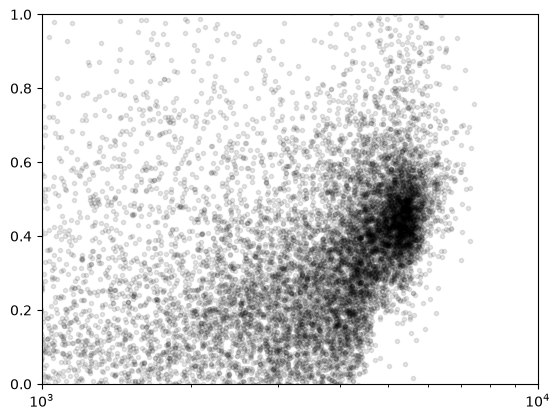

In [66]:
t_ = t[(t['z_photo'] > 0.2) &
       (t['z_photo'] < 0.3)]

kcor_r = calc_kcor('r', t_['z_photo'],'g - r', t_['g_kronflux_mag'] - t_['r_kronflux_mag'])
kcor_i = calc_kcor('i',t_['z_photo'],'g - i', t_['g_kronflux_mag'] - t_['i_kronflux_mag'])


plt.plot(10**t_['age_photo'], t_['r_kronflux_mag'] - kcor_r - t_['i_kronflux_mag'] + kcor_i, 'k.', alpha=0.1)

plt.ylim(0, 1)
plt.xlim(1e3, 1e4)
plt.xscale('log')
plt.show()

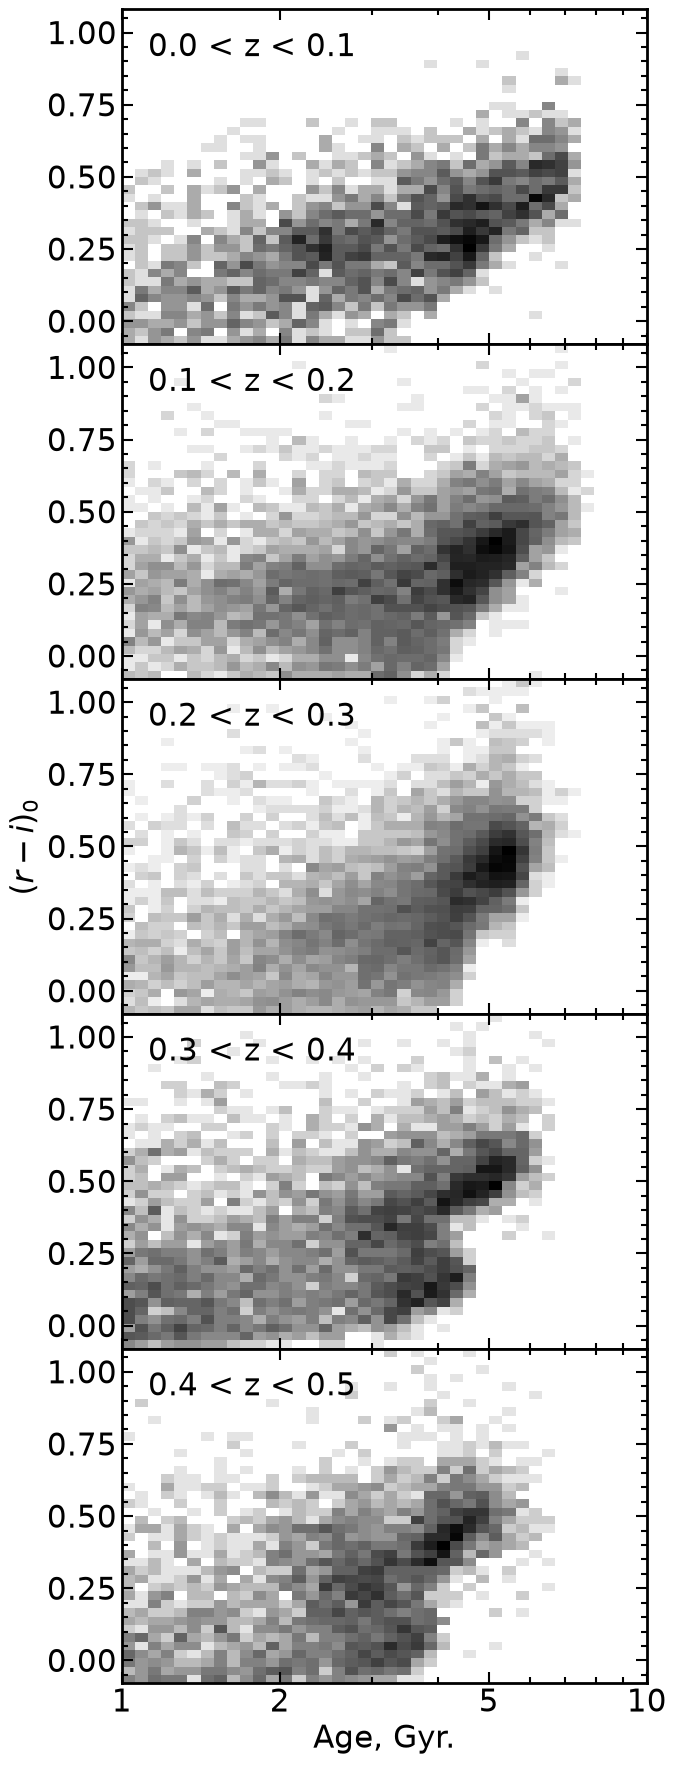

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib
import matplotlib.gridspec as gridspec

matplotlib.rcParams.update({'font.size': 22})

zbins = np.arange(0.0, 0.6, 0.1)

fig = plt.figure(figsize=(7, 18))
gs = gridspec.GridSpec(
    len(zbins) - 1, 1,
    hspace=0.00,
    left=0.18,
    right=0.93,
    bottom=0.06,
    top=0.99
)

axes = []

# logarithmic age bins (1--10 Gyr)
xbins = np.logspace(0, 1, 41)
ybins = np.linspace(-0.08, 1.08, 41)

for i in range(len(zbins) - 1):

    if i == 0:
        ax = fig.add_subplot(gs[i])
    else:
        ax = fig.add_subplot(gs[i], sharex=axes[0], sharey=axes[0])

    axes.append(ax)

    zmin = zbins[i]
    zmax = zbins[i + 1]

    t_ = t[
        (t['z_photo'] > zmin) &
        (t['z_photo'] < zmax)
    ]

    kcor_r = calc_kcor(
        'r',
        t_['z_photo'],
        'g - r',
        t_['g_kronflux_mag'] - t_['r_kronflux_mag']
    )

    kcor_i = calc_kcor(
        'i',
        t_['z_photo'],
        'g - i',
        t_['g_kronflux_mag'] - t_['i_kronflux_mag']
    )

    # log10(Age/Myr) -> Age (Gyr)
    x = np.power(
        10.0,
        np.asarray(t_['age_photo'], dtype=float)
    ) / 1e3

    y = np.asarray(
        (t_['r_kronflux_mag'] - kcor_r) -
        (t_['i_kronflux_mag'] - kcor_i),
        dtype=float
    )

    mask = np.isfinite(x) & np.isfinite(y)
    mask &= (x >= 1.0) & (x <= 10.0)
    mask &= (y > -0.08) & (y < 1.08)

    x = x[mask]
    y = y[mask]

    ax.hist2d(
        x,
        y,
        bins=[xbins, ybins],
        cmap='Greys',
        norm=LogNorm()
    )

    ax.set_xscale('log')

    ax.text(
        0.05,
        0.93,
        f'{zmin:.1f} < z < {zmax:.1f}',
        transform=ax.transAxes,
        va='top'
    )

    ax.set_xlim(1.0, 10.0)
    ax.set_ylim(-0.08, 1.08)

    if i == 2:
        ax.set_ylabel(r'$(r-i)_0$')

    if i != len(zbins) - 2:
        ax.tick_params(labelbottom=False)
    else:
        ax.set_xlabel('Age, Gyr.')

    # Major ticks
    ax.set_xticks([1, 2, 5, 10])
    ax.set_xticklabels(['1', '2', '5', '10'])

    # Minor ticks
    ax.minorticks_on()

    ax.tick_params(
        which='both',
        direction='in',
        top=True,
        right=True
    )

    ax.tick_params(
        which='major',
        length=8,
        width=1.5
    )

    ax.tick_params(
        which='minor',
        length=4,
        width=1.5
    )

    for spine in ax.spines.values():
        spine.set_linewidth(2)

plt.savefig('age_color.pdf')

plt.show()
